# 07 — What are you estimating?

## The question

> What was the average effluent TSS this week?

It is a plain question with at least four defensible answers, and this notebook exists
because they are not the same number and nobody says which one they meant. What the
number is *for* decides it: a concentration to report, a mass to set against a load
limit, or a level to put on a dashboard.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from notebooks._data import connect, storm_window
from notebooks._style import apply_style, save, stamp

apply_style()
pd.set_option("display.width", 130)

conn = connect()
storm_start, storm_end = (pd.Timestamp(t) for t in storm_window())
SIGNALS = ("EFFLUENT:FLOW:FLOW", "EFFLUENT:FLOW:TSS", "EFFLUENT:FLOW:NH4")
raw = pd.read_sql(
    "SELECT ts, signal_id, value FROM reading "
    "WHERE signal_id = ANY(%s) AND quality = 0 AND value IS NOT NULL",
    conn,
    params=(list(SIGNALS),),
)
week = pd.date_range(
    "2026-09-22", "2026-09-29", freq="1min", tz="UTC", inclusive="left"
)


def hold(signal):
    """The signal as a step function, sampled every minute.

    A change-triggered historian writes a row when the value moves, so the value
    *between* rows is the last row's value. Holding it forward is not filling a gap;
    it is reading the storage convention correctly (notebook 02).
    """
    s = raw[raw.signal_id == signal].set_index("ts").value.sort_index()
    return s.resample("1min").last().reindex(week).ffill().bfill()


flow, tss, nh4 = hold(SIGNALS[0]), hold(SIGNALS[1]), hold(SIGNALS[2])
print(
    f"{len(week):,} minutes; readings used: "
    + ", ".join(
        f"{s.split(':')[-1]} {int((raw.signal_id == s).sum()):,}" for s in SIGNALS
    )
)

10,080 minutes; readings used: FLOW 144,767, TSS 125,886, NH4 702


```output
10,080 minutes; readings used: FLOW 144,767, TSS 125,886, NH4 702
```

Effluent flow, TSS and ammonia, `Good`-quality readings only, held forward onto a
one-minute grid. Holding a value forward between readings is not filling a gap: the
historian writes a row when the value *moves*, so the value between rows is the last
row's value. That is the storage convention read correctly, and it is what notebook 02
was building towards.

## Four averages of one column

In [2]:
def four_averages(signal, concentration):
    readings = raw[raw.signal_id == signal].set_index("ts").value
    return pd.Series(
        {
            "mean of the readings": readings.mean(),
            "mean of hourly means": readings.resample("1h").mean().mean(),
            "time-weighted": concentration.mean(),
            "flow-weighted": (concentration * flow).sum() / flow.sum(),
        }
    )


averages = pd.DataFrame(
    {
        "TSS [mg/L]": four_averages(SIGNALS[1], tss),
        "NH4 [mg/L]": four_averages(SIGNALS[2], nh4),
    }
)
print(averages.round(3).to_string())

                      TSS [mg/L]  NH4 [mg/L]
mean of the readings      18.491       7.437
mean of hourly means      17.118       7.884
time-weighted             17.113       7.824
flow-weighted             18.656       7.901


```output
                      TSS [mg/L]  NH4 [mg/L]
mean of the readings      18.491       7.437
mean of hourly means      17.118       7.884
time-weighted             17.113       7.824
flow-weighted             18.656       7.901
```

For TSS the four averages run from **17.113** to **18.656** mg/L — about nine per cent
between the smallest and the largest, with nothing wrong with the data. Each is exact for
a different question:

* the **mean of the readings**, **18.491**, is the average row in the table, which is a
  fact about the historian;
* the **mean of hourly means**, **17.118**, gives every hour one vote;
* the **time-weighted mean**, **17.113**, is the concentration at a randomly chosen
  moment;
* the **flow-weighted mean**, **18.656**, is the concentration of the water that actually
  left the plant: the mass divided by the volume.

Ammonia spreads much less, from **7.824** to **7.901**, because it moves less with the
flow.

## Why the plain average lands where it does

In [3]:
readings = raw[raw.signal_id == SIGNALS[1]]
in_storm = (readings.ts >= storm_start) & (readings.ts < storm_end)
minutes_in_storm = (week >= storm_start) & (week < storm_end)

shares = pd.Series(
    {
        "of the minutes of the week": minutes_in_storm.mean(),
        "of the volume that left the plant": flow[minutes_in_storm].sum() / flow.sum(),
        "of the TSS readings written": in_storm.mean(),
        "of the TSS load (mass)": (tss * flow)[minutes_in_storm].sum()
        / (tss * flow).sum(),
    }
)
print((100 * shares).round(1).astype(str).add(" %").to_string())

of the minutes of the week           1.2 %
of the volume that left the plant    2.3 %
of the TSS readings written          0.2 %
of the TSS load (mass)               5.4 %


```output
of the minutes of the week           1.2 %
of the volume that left the plant    2.3 %
of the TSS readings written          0.2 %
of the TSS load (mass)               5.4 %
```

One number stands out. The storm is **1.2 %** of the minutes, **2.3 %** of the volume and
**5.4 %** of the TSS load: two hours carry more than four times their share of the mass,
because flow *and* concentration are both high in them. A time-weighted average sees the
first of those numbers, a flow-weighted average sees the second, and only a load sees the
third.

The storm is *not* why. Only **0.2 %** of the TSS readings were written in it — the
opposite of the flow meter in notebook 04, which wrote almost a third of its week there.
So where does a plain average of readings get its weights from?

In [4]:
hourly = pd.DataFrame(
    {
        "flow": flow.resample("1h").mean(),
        "tss": tss.resample("1h").mean(),
        "readings": readings.set_index("ts").value.resample("1h").count(),
    }
).fillna({"readings": 0})
third = pd.qcut(
    hourly.flow, 3, labels=["lowest-flow third", "middle third", "highest-flow third"]
)
by_flow = hourly.groupby(third, observed=True).agg(
    hours=("flow", "size"),
    mean_flow=("flow", "mean"),
    time_weighted_tss=("tss", "mean"),
    readings=("readings", "sum"),
)
by_flow["share of readings"] = 100 * by_flow.readings / by_flow.readings.sum()
print(
    by_flow.round(
        {"mean_flow": 0, "time_weighted_tss": 2, "share of readings": 1}
    ).to_string()
)

quiet = readings[readings.ts.dt.hour < 5]
print(
    f"\nreadings written between 00:00 and 05:00, all week: {len(quiet):,}"
    f" of {len(readings):,}"
)

                    hours  mean_flow  time_weighted_tss  readings  share of readings
flow                                                                                
lowest-flow third      56     1485.0              13.01     21842               17.4
middle third           56     1729.0              16.84     55542               44.1
highest-flow third     56     1975.0              21.50     48502               38.5

readings written between 00:00 and 05:00, all week: 99 of 125,886


```output
                    hours  mean_flow  time_weighted_tss  readings  share of readings
flow                                                                                
lowest-flow third      56     1485.0              13.01     21842               17.4
middle third           56     1729.0              16.84     55542               44.1
highest-flow third     56     1975.0              21.50     48502               38.5

readings written between 00:00 and 05:00, all week: 99 of 125,886
```

The plain average of readings lands close to the flow-weighted one, **18.491** against
**18.656**, and the tempting explanation is the storm. It is not. What is happening is
quieter. The historian writes a row when the value moves, and overnight, at the lowest
flow, TSS barely moves: **99** of the week's readings were written between midnight and
05:00. The lowest-flow third of the week, where TSS is **13.01** mg/L, holds **17.4 %** of
the readings for a third of the time; the highest-flow third, at **21.50**, holds
**38.5 %**. A plain average of readings therefore leans towards the high-flow, high-TSS
hours, which is the direction flow-weighting leans too.

**It lands near the flow-weighted answer for a reason that has nothing to do with flow.**
The historian's row rate happens to rise with flow, so the plain mean happens to drift the
way flow-weighting does. Change the deadband or the plant and the agreement goes. Ammonia
shows it going: its plain mean, **7.437**, sits *below* its time-weighted mean of
**7.824**, the opposite direction.

## The load, and where it went

volume discharged : 290,567 m3
TSS load          : 5,421 kg  (volume-weighted mean 18.66 mg/L)
storm's two hours : 295 kg
mean x volume     : 4,973 kg  (the time-weighted mean times the volume: the classic shortcut)


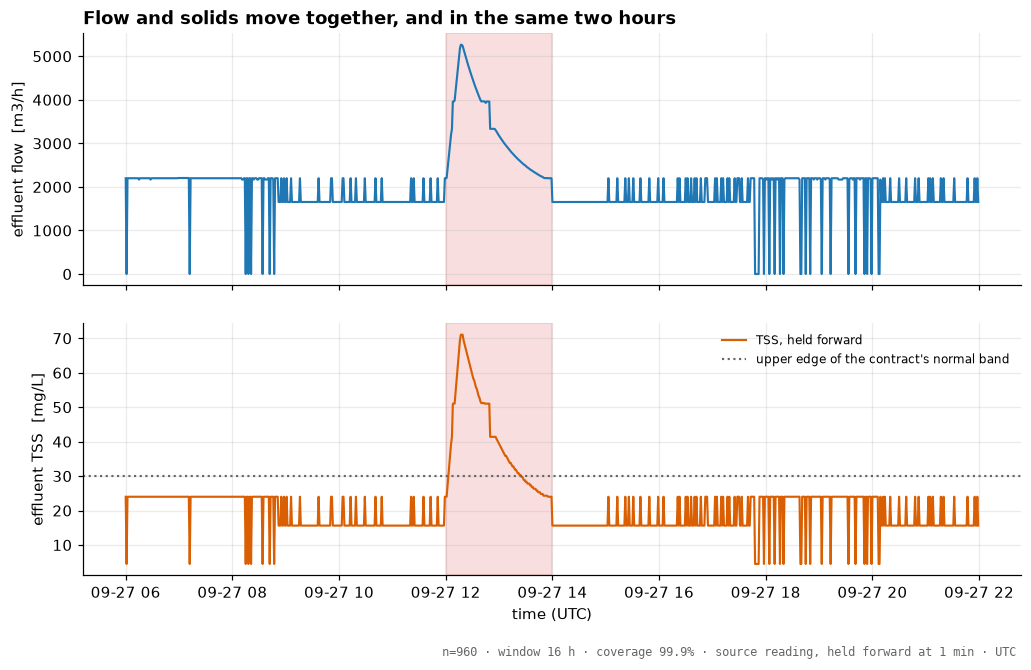

In [5]:
volume_m3 = flow.sum() / 60  # m3/h held for one minute each
load_kg = (tss * flow).sum() / 60 / 1000  # (g/m3) * (m3/h) * h = g
print(f"volume discharged : {volume_m3:,.0f} m3")
print(
    f"TSS load          : {load_kg:,.0f} kg  "
    f"(volume-weighted mean {1000 * load_kg / volume_m3:.2f} mg/L)"
)
print(f"storm's two hours : {(tss * flow)[minutes_in_storm].sum() / 60 / 1000:,.0f} kg")
print(
    f"mean x volume     : {tss.mean() * volume_m3 / 1000:,.0f} kg  "
    "(the time-weighted mean times the volume: the classic shortcut)"
)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
around = (week >= storm_start - pd.Timedelta(hours=6)) & (
    week < storm_end + pd.Timedelta(hours=8)
)
top.plot(week[around], flow[around])
top.set_ylabel("effluent flow  [m3/h]")
bottom.plot(week[around], tss[around], color="#d95f02", label="TSS, held forward")
bottom.axhline(
    30, color="#666666", linestyle=":", label="upper edge of the contract's normal band"
)
bottom.set_ylabel("effluent TSS  [mg/L]")
bottom.set_xlabel("time (UTC)")
bottom.legend(loc="upper right", fontsize=8)
for ax in (top, bottom):
    ax.axvspan(storm_start, storm_end, color="#d62728", alpha=0.15)
top.set_title(
    "Flow and solids move together, and in the same two hours",
    loc="left",
    fontweight="bold",
)
stamp(
    bottom,
    tss[around],
    window="16 h",
    source="reading, held forward at 1 min",
    expected_s=60,
)
fig.subplots_adjust(hspace=0.15)
save(fig, "07_storm_load")

```output
volume discharged : 290,567 m3
TSS load          : 5,421 kg  (volume-weighted mean 18.66 mg/L)
storm's two hours : 295 kg
mean x volume     : 4,973 kg  (the time-weighted mean times the volume: the classic shortcut)
```

The plant discharged **290,567** m³ and **5,421** kg of suspended solids in the week, a
volume-weighted mean of **18.66** mg/L. The storm's two hours were **295** kg of that.

The line that matters is the last: **the time-weighted mean times the volume gives
4,973 kg**, about eight per cent short of the real load. It is the standard shortcut, it
needs no flow-weighting and no held grid, and it is wrong by exactly the covariance
between flow and concentration, which is the storm.

## The averaging period decides whether it was a problem

In [6]:
frame = pd.DataFrame({"tss": tss, "flow": flow})


def flow_weighted(x):
    return (x.tss * x.flow).sum() / x.flow.sum()


storm_hours = frame[minutes_in_storm]
day = frame[(frame.index >= "2026-09-27") & (frame.index < "2026-09-28")]
print(f"{'window':38} {'time-weighted':>14} {'flow-weighted':>14}")
for label, window in (
    ("the storm's two hours", storm_hours),
    ("27 September, 24 hours", day),
    ("the whole week", frame),
):
    print(f"{label:38} {window.tss.mean():14.2f} {flow_weighted(window):14.2f}")
print("\nreference line: 30 mg/L")

window                                  time-weighted  flow-weighted
the storm's two hours                           40.79          44.90
27 September, 24 hours                          18.83          22.08
the whole week                                  17.11          18.66

reference line: 30 mg/L


```output
window                                  time-weighted  flow-weighted
the storm's two hours                           40.79          44.90
27 September, 24 hours                          18.83          22.08
the whole week                                  17.11          18.66

reference line: 30 mg/L
```

The same storm reads very differently depending on the window you average it over. Over
its own two hours the effluent TSS averaged **40.79** mg/L by time and **44.90**
flow-weighted, past the 30 mg/L line (the top of the contract's *normal band*, not a
permit, but the shape of the point is the same for a real limit). Averaged over 27
September it is **18.83** and **22.08**, and both are under it. Over the whole week,
**17.11** and **18.66**.

Nothing about the plant changed between those three rows. A limit written as a two-hour
mean and a limit written as a daily mean are different rules for identical water, and the
flow-weighted figure is the larger in every row.

## Which estimand for which question

| the question | the estimand | how |
|---|---|---|
| what concentration did the receiving water see, on average? | **flow-weighted mean** | `sum(c * q) / sum(q)` on a held grid |
| how much mass left the plant? | **load** | `sum(c * q * dt)`; never mean concentration × volume |
| what was a typical moment like? | **time-weighted mean** | the mean of the held grid |
| a level to trend on a dashboard | **mean of hourly means** | carry `n` (notebook 04) |
| what is in the table? | **mean of the readings** | a fact about the historian, not the plant |

The first two rows are the ones a regulator means, and they are the two that a plain
`AVG(value)` cannot give you. The last row is the one most analyses report.

## Takeaways

- **One column has four averages**, and for effluent TSS they run from **17.113** to
  **18.656** mg/L with nothing wrong with the data. Say which one you mean.
- **The storm is 1.2 % of the time, 2.3 % of the volume and 5.4 % of the mass.** Which
  of those you weight by decides how much it counts.
- **A plain average can land near the right answer for the wrong reason.** TSS's is
  within a whisker of the flow-weighted mean because the historian is quiet overnight
  (only **99** readings between midnight and 05:00), and ammonia's plain mean falls on the
  other side of the time-weighted one.
- **Mean concentration × volume is not a load.** It gives **4,973** kg against a real
  **5,421** kg.
- **The averaging window can decide whether an event was a problem**: **44.90** mg/L over
  the storm, **22.08** over its day, against a 30 mg/L reference.

## Exercises

1. **Do it for ammonia.** Repeat the load and the averaging-window tables for
   `EFFLUENT:FLOW:NH4`, which has 702 readings. How much of the answer depends on the
   hold-forward convention, and how would you test it?
2. **Change the hold.** The grid holds each reading until the next. Replace it with
   linear interpolation and recompute the flow-weighted mean. Which of the four averages
   move, and by how much?
3. **Find the deadband's fingerprint.** Reading counts fell to 99 overnight. Using the
   `deadband` column of the `signal` table, predict how many readings a 0.5 mg/L deadband
   would have written instead, and check it against the seed.
4. **Weight by something else.** A treatment plant is also billed by energy. Compute the
   *power-weighted* mean effluent TSS and say what question it answers, if any.

---

**Next:** [08 — Rolling-origin validation](08-rolling-origin-validation.ipynb) ·
**Back to the series** [README](README.md) ·
**Previous:** [06 — Detrending and differencing](06-detrending-and-differencing.ipynb)